In [1]:
%cd ..

c:\Users\HusPhil\Documents\fourth-year-cs\thesis\dctroy\project_dctroy


# PHASE 1A: Frequency Weighting Pipeline 

## Load the ip2p pipeline to get vae

In [2]:
from utils.diffusion_model import create_ip2p_pipeline


ip2p_pipeline = create_ip2p_pipeline()
vae_encoder = ip2p_pipeline.vae

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\HusPhil\Documents\fourth-year-cs\thesis\echomask\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\HusPhil\Documents\fourth-year-cs\thesis\echomask\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\HusPhil\Documents\fourth-year-cs\thesis\echomask\venv\Lib\site-packages\lpips\weights\v0.1\alex.pth
Using device: cuda


c:\Users\HusPhil\Documents\fourth-year-cs\thesis\echomask\venv\Lib\site-packages\diffusers\pipelines\pipeline_loading_utils.py:333: FutureWarning: You are loading the variant fp16 from timbrooks/instruct-pix2pix via `revision='fp16'`. This behavior is deprecated and will be removed in diffusers v1. One should use `variant='fp16'` instead. However, it appears that timbrooks/instruct-pix2pix currently does not have the required variant filenames in the 'main' branch. 
 The Diffusers team and community would be very grateful if you could open an issue: https://github.com/huggingface/diffusers/issues/new with the title 'timbrooks/instruct-pix2pix is missing fp16 files' so that the correct variant file can be added.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_instruct_pix2pix.StableDiffusionInstructPix2PixPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


## Load config files

In [3]:
import yaml

# Load config
with open("configs/phase1a.yaml") as f:
    cfg = yaml.safe_load(f)


with open("configs/secrets.yaml") as f:
    secrets_cfg = yaml.safe_load(f)

## Initialize the logger

In [4]:
from pathlib import Path
from utils.logger import write_log, init_logger, close_logger
from utils.globals import generate_timestamp_based_name


LOG_DIR = Path(cfg["RESULTS"]["BASE_PATH"], cfg["RESULTS"]["LOGGING"]["BASE_PATH"])
LOG_DIR.mkdir(exist_ok=True, parents=True)

log_filename = LOG_DIR / generate_timestamp_based_name("experiment_log_", ".log")
logger = init_logger(log_filename)

Initializing logger: results\phase1a\logs\experiment_log_02-16-2026_at_11-56-22_AM.log


## Load experiment configs

In [5]:
from pathlib import Path
import re
from utils.frequency_weight import create_frequency_weight_mask
from utils.data_controller import (
    check_paths_exist,
    loadstate_last_processed_image,
    STATE_TRACKER_FILEPATH,
)

if not STATE_TRACKER_FILEPATH.exists():
    state_image_id = input(
        "No state tracker file found.\nType img_id or escape to cancel: "
    ).lower()

    if state_image_id and re.match(r"^[ab]_\d{3}$", state_image_id):
        with open(STATE_TRACKER_FILEPATH, "w") as f:
            yaml.safe_dump({"LAST_PROCESSED_IMAGE_ID": state_image_id}, f)

phase_name = cfg["PHASE_NAME"]
N = cfg["BATCH_SIZE"]
current_img_id = loadstate_last_processed_image()
current_filename = f"{current_img_id}_orig.png"
frequency_weighting = cfg["FREQUENCY_WEIGHTING"]
decay_strength = cfg["FREQUENCY_WEIGHT_DECAY"]


dataset_root = Path(cfg["DATASET"]["BASE_PATH"])
metadata_dir = cfg["DATASET"]["METADATA_DIR_NAME"]

dataset_metadata_path = cfg["DATASET"]["GSHEET_METADATA_FILE"]

# UNCOMMENT FOR LOCAL TESTING
# dataset_metadata_path = Path(
#     dataset_root / metadata_dir / cfg["DATASET"]["METADATA_FILE_NAME"]
#     if metadata_dir
#     else dataset_root / cfg["DATASET"]["METADATA_FILE_NAME"]
# )

dataset_img_src_path = Path(dataset_root / cfg["DATASET"]["SRC_DIR_NAME"])
dataset_img_src_orig_path = Path(dataset_img_src_path / cfg["DATASET"]["ORIG_DIR_NAME"])
dataset_img_src_edited_path = Path(
    dataset_img_src_path / cfg["DATASET"]["EDIT_DIR_NAME"]
)

results_root = Path(cfg["RESULTS"]["BASE_PATH"])
results_protected_path = Path(results_root / cfg["RESULTS"]["PROTECTED_DIR_NAME"])
results_compressed_path = Path(results_root / cfg["RESULTS"]["COMPRESSED_DIR_NAME"])
results_purified_path = Path(results_root / cfg["RESULTS"]["PURIFIED_DIR_NAME"])

results_sheet_name = cfg["RESULTS"]["RESULT_GSHEET"]["NAME"]
results_sheet_tab_name = cfg["RESULTS"]["RESULT_GSHEET"]["TAB_NAME"]

temps_root = Path(cfg["TEMPS"]["BASE_PATH"])

upload_root = Path(cfg["UPLOAD"]["BASE_PATH"])
upload_max_workers = cfg["UPLOAD"]["MAX_UPLOAD_WORKERS"]

frequency_weight = create_frequency_weight_mask(frequency_weighting, decay_strength)
jpeg_quality = 95

paths_to_check = {
    "dataset_root": dataset_root,
    "dataset_img_src_path": dataset_img_src_path,
    "dataset_img_src_orig_path": dataset_img_src_orig_path,
    "dataset_img_src_edited_path": dataset_img_src_edited_path,
}

check_paths_exist(paths_to_check)
write_log(logger, "All required dataset paths exist.", verbose=True)

log_message = f"""LOADED CONFIGS:

[BATCHING]
- BATCH_SIZE (N): {N}
- Last processed image ID: {current_img_id}
- Current filename: {current_filename}

[FREQUENCY WEIGHTING]
- Enabled: {frequency_weighting}
- Decay strength: {decay_strength}
- JPEG quality: {jpeg_quality}

[DATASET PATHS]
- Dataset root: {dataset_root}
- Metadata file: {dataset_metadata_path}
- Source image root: {dataset_img_src_path}
- Original images dir: {dataset_img_src_orig_path}
- Edited images dir: {dataset_img_src_edited_path}

[RESULTS PATHS]
- Results root: {results_root}
- Protected outputs: {results_protected_path}
- Compressed outputs: {results_compressed_path}
- Purified outputs: {results_purified_path}
- Result sheets: 
    - Sheet name: {results_sheet_name}
    - Tab name: {results_sheet_tab_name}

[TEMP PATHS]
- Temps root: {temps_root}

[UPLOAD SETTINGS]
- Upload root: {upload_root}
- Max upload workers: {upload_max_workers}


"""

write_log(logger, log_message, verbose=True)

[INFO] All required dataset paths exist.
[INFO] LOADED CONFIGS:

[BATCHING]
- BATCH_SIZE (N): 1
- Last processed image ID: a_010
- Current filename: a_010_orig.png

[FREQUENCY WEIGHTING]
- Enabled: high-pass
- Decay strength: 1.0
- JPEG quality: 95

[DATASET PATHS]
- Dataset root: datasets\phase1a
- Metadata file: https://docs.google.com/spreadsheets/d/15PD4xEoMOXpEnOf7-WwiVhiOAJZks7iHWs1Dbtgc4Qg/export?format=csv&gid=0
- Source image root: datasets\phase1a\src
- Original images dir: datasets\phase1a\src\orig
- Edited images dir: datasets\phase1a\src\edited

[RESULTS PATHS]
- Results root: results\phase1a
- Protected outputs: results\phase1a\protected
- Compressed outputs: results\phase1a\compressed
- Purified outputs: results\phase1a\purified
- Result sheets: 
    - Sheet name: project_dctroy_results
    - Tab name: PHASE_1A_testing

[TEMP PATHS]
- Temps root: temp

[UPLOAD SETTINGS]
- Upload root: research\dctroy\phase1a
- Max upload workers: 8





## Loading the dataset

In [6]:
from utils.data_controller import load_dataset
import pandas as pd

metadata_df = pd.read_csv(dataset_metadata_path)

In [7]:
metadata_df

,img_id,omni_edit_id,editing_task,edit_prompt,source,orig_img_url,edited_img_url
0,a_000,task_obj_swap_joint_mask_363532,swap,Swap the reddish leather jacket with a royal b...,train-00300-of-00571.parquet,https://res.cloudinary.com/dajw2wgld/image/upl...,https://res.cloudinary.com/dajw2wgld/image/upl...
1,a_001,task_obj_add_448994,addition,Add bare muscular chest and back to the man.,train-00000-of-00571.parquet,https://res.cloudinary.com/dajw2wgld/image/upl...,https://res.cloudinary.com/dajw2wgld/image/upl...
2,a_002,task_obj_add_151836,addition,Add a harness with red straps over the man's t...,train-00000-of-00571.parquet,https://res.cloudinary.com/dajw2wgld/image/upl...,https://res.cloudinary.com/dajw2wgld/image/upl...
3,a_003,task_obj_add_273266,addition,Add a teal nurse's cap on the woman's head.,train-00000-of-00571.parquet,https://res.cloudinary.com/dajw2wgld/image/upl...,https://res.cloudinary.com/dajw2wgld/image/upl...
4,a_004,task_obj_add_497558,addition,Add pinstriped suits to the three men.,train-00000-of-00571.parquet,https://res.cloudinary.com/dajw2wgld/image/upl...,https://res.cloudinary.com/dajw2wgld/image/upl...
...,...,...,...,...,...,...,...
195,a_195,task_obj_swap_rand_mask_60955,swap,"Swap the red kimono with a light, long-sleeved...",train-00300-of-00571.parquet,https://res.cloudinary.com/dajw2wgld/image/upl...,https://res.cloudinary.com/dajw2wgld/image/upl...
196,a_196,task_obj_swap_joint_mask_453534,swap,Swap the black and white striped shirt with a ...,train-00300-of-00571.parquet,https://res.cloudinary.com/dajw2wgld/image/upl...,https://res.cloudinary.com/dajw2wgld/image/upl...
197,a_197,task_obj_swap_joint_mask_496778,swap,"Swap the tactical vest with a light grey, long...",train-00300-of-00571.parquet,https://res.cloudinary.com/dajw2wgld/image/upl...,https://res.cloudinary.com/dajw2wgld/image/upl...
198,a_198,task_obj_swap_rand_mask_249766,swap,Swap the metallic armor-like top with a fringe...,train-00300-of-00571.parquet,https://res.cloudinary.com/dajw2wgld/image/upl...,https://res.cloudinary.com/dajw2wgld/image/upl...


In [8]:
no_cache = False

exclude_current = current_img_id != "a_000"
# exclude_current = True

img_id_list, edit_prompts, img_src_orig_paths, img_src_edited_paths = load_dataset(
    metadata_df,
    N,
    current_img_id,
    dataset_img_src_orig_path,
    dataset_img_src_edited_path,
    no_cache=no_cache,
    exclude_current=exclude_current,
)

log_message = f"""[LOADING DATASET]
No cache: {no_cache}

LOADED SUCCESSFULLY

"""
write_log(logger, log_message, verbose=True)

[INFO] [LOADING DATASET]
No cache: False

LOADED SUCCESSFULLY




## Loading the batch and edit prompts

In [9]:
from utils.data_controller import get_filepath_batch


current_batch = get_filepath_batch(
    directory=dataset_img_src_orig_path,
    current_filename=current_filename,
    exclude_current=exclude_current,
    batch_size=N,
)


if not current_batch:
    from IPython.display import display, Javascript

    display(Javascript('alert("⚠️ Alert: Current batch is empty!");'))
    raise ValueError("No more images to process.")

log_message = f"""[BATCH INITIALIZATION]

[BATCH SELECTION]
- Starting image ID: {current_img_id}
- Source directory: {dataset_img_src_orig_path}
- Current filename: {current_filename}
- Exclude current image: True
- Metadata source: {dataset_metadata_path}
- Loaded batch size: {len(current_batch)}

[BATCH CONTENT]
- Batch size (N): {N}
- Batch filenames:
{chr(10).join(f"  - {fname}" for fname in current_batch)}

[EDIT PROMPTS]
- Number of prompts requested: {N}
- Loaded prompts: {len(edit_prompts)}

"""

write_log(logger, log_message, verbose=True)

[INFO] [BATCH INITIALIZATION]

[BATCH SELECTION]
- Starting image ID: a_010
- Source directory: datasets\phase1a\src\orig
- Current filename: a_010_orig.png
- Exclude current image: True
- Metadata source: https://docs.google.com/spreadsheets/d/15PD4xEoMOXpEnOf7-WwiVhiOAJZks7iHWs1Dbtgc4Qg/export?format=csv&gid=0
- Loaded batch size: 1

[BATCH CONTENT]
- Batch size (N): 1
- Batch filenames:
  - datasets\phase1a\src\orig\a_011_orig.png

[EDIT PROMPTS]
- Number of prompts requested: 1
- Loaded prompts: 1




## Applying Perturbation 

In [10]:
from utils.optimizer import generate_pgd_dct_protection
from utils.jpeg_dct import jpeg_decode, tensor_to_pil
from utils.data_controller import save_image_lossless
from utils.evaluation import advclean, jpeg_compress


iters = 10
eps = 1.0
alpha = 0.1

img_protected_orig_paths = []
img_protected_purified_orig_paths = []
img_protected_compressed_orig_paths = []

for img_id, y, cb, cr, loss in generate_pgd_dct_protection(
    iters,
    eps,
    alpha,
    current_batch,
    jpeg_quality,
    vae_encoder,
    frequency_weight,
):
    img_src_orig_path = Path(f"{dataset_img_src_orig_path}/{img_id}_orig.png")
    img_src_edited_path = Path(f"{dataset_img_src_edited_path}/{img_id}_edited.png")

    img_protected_edited_path = Path(
        f"{results_protected_path}/orig/{img_id}_protected_orig.png"
    )
    img_protected_purified_edited_path = Path(
        f"{results_purified_path}/orig/{img_id}_protected_purified_orig.png"
    )
    img_protected_compressed_edited_path = Path(
        f"{results_compressed_path}/orig/{img_id}_protected_compressed_orig.png"
    )

    protected_img = tensor_to_pil(
        jpeg_decode(y, cb, cr, jpeg_quality=jpeg_quality, H=512, W=512, ste=False)
    )
    compressed_protected_img = jpeg_compress(
        protected_img, quality=jpeg_quality, verbose=True
    )
    purified_protected_img = advclean(compressed_protected_img)

    save_image_lossless(protected_img, img_protected_edited_path)
    save_image_lossless(compressed_protected_img, img_protected_purified_edited_path)
    save_image_lossless(purified_protected_img, img_protected_compressed_edited_path)

    img_protected_orig_paths.append(img_protected_edited_path)
    img_protected_compressed_orig_paths.append(img_protected_compressed_edited_path)
    img_protected_purified_orig_paths.append(img_protected_purified_edited_path)

    log_message = f"{img_id} final loss at: {loss:.4f}\n\n"
    write_log(logger, log_message, verbose=True)

log_message = f"""[PERTURBATION PIPELINE]

- PGD iterations: {iters}
- Alpha: {alpha}
- Epsilon: {eps}

[INPUT BATCH]
- Number of images processed: {len(img_protected_orig_paths)}
- Image IDs:
{chr(10).join(f"  - {img_id}" for img_id in img_id_list) if img_id_list else "  (not populated yet)"}

"""

write_log(logger, log_message, verbose=True)

Opening image from path: datasets\phase1a\src\orig\a_011_orig.png


c:\Users\HusPhil\Documents\fourth-year-cs\thesis\echomask\venv\Lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
PGD Attack (Full Channel):   0%|          | 0/10 [00:00<?, ?it/s]c:\Users\HusPhil\Documents\fourth-year-cs\thesis\echomask\venv\Lib\site-packages\diffusers\models\attention_processor.py:2765: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  hidden_states = F.scaled_dot_product_attention(
Loss: 457.500000: 100%|██████████| 10/10 [00:03<00:00,  2.88it/s]


Protected: a_011 

Raw image size: 768.00 bytes, Compressed JPEG size: 61.41 KB
[INFO] a_011 final loss at: 457.5000


[INFO] [PERTURBATION PIPELINE]

- PGD iterations: 10
- Alpha: 0.1
- Epsilon: 1.0

[INPUT BATCH]
- Number of images processed: 1
- Image IDs:
  - a_011




## List the pairs of Image to be edited and its edit prompt

In [11]:
img_to_be_edited_paths = [
    *img_protected_orig_paths,
    *img_protected_compressed_orig_paths,
    *img_protected_purified_orig_paths,
]

edit_prompts = [
    *edit_prompts,
    *edit_prompts,
    *edit_prompts,
]

## Create the image batch editing generators

In [12]:
from utils.diffusion_model import edit_images_with_ip2p_batch_looping_generator


edited_images_generator = edit_images_with_ip2p_batch_looping_generator(
    image_paths=img_to_be_edited_paths,
    instructions=edit_prompts,
    ip2p_pipe=ip2p_pipeline,
)

log_message = "[CREATING EDIT GENERATORS]\n\n"

write_log(logger, log_message, verbose=True)

[INFO] [CREATING EDIT GENERATORS]




## Generate the edited images

  0%|          | 0/50 [00:00<?, ?it/s]

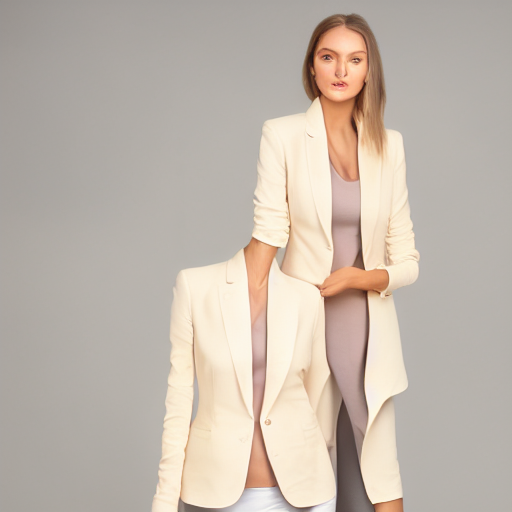

Add a light beige blazer over the woman's shirt.
results\phase1a\protected\edited\a_011_protected_edited.png


  0%|          | 0/50 [00:00<?, ?it/s]

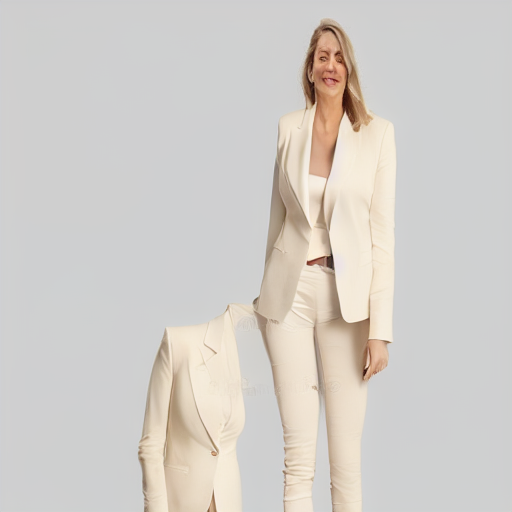

Add a light beige blazer over the woman's shirt.
results\phase1a\compressed\edited\a_011_protected_compressed_edited.png


  0%|          | 0/50 [00:00<?, ?it/s]

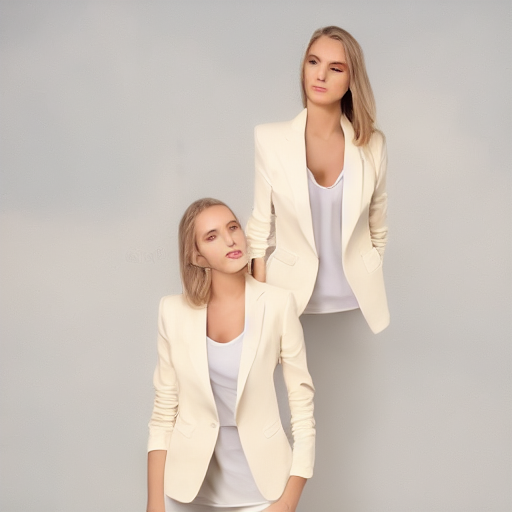

Add a light beige blazer over the woman's shirt.
results\phase1a\purified\edited\a_011_protected_purified_edited.png
[INFO] [EDIT FINISHED]




In [13]:
from collections import defaultdict

edited_images_path_dict = defaultdict(list)

for i, edited_img in enumerate(edited_images_generator):
    display(edited_img)
    print(edit_prompts[i])

    dir_names = [
        results_protected_path,
        results_compressed_path,
        results_purified_path,
    ]

    suffix_id_list = [
        "",
        "_" + cfg["RESULTS"]["COMPRESSED_DIR_NAME"],
        "_" + cfg["RESULTS"]["PURIFIED_DIR_NAME"],
    ]

    img_id = img_id_list[i % len(img_id_list)]
    dir_name = dir_names[i // len(img_id_list)]
    suffix_id = suffix_id_list[i // len(img_id_list)]

    edited_img_save_path = Path(
        f"{dir_name}/edited/{img_id}_protected{suffix_id}_edited.png"
    )

    edited_images_path_dict.setdefault(dir_name.stem, []).append(edited_img_save_path)

    print(edited_img_save_path)

    save_image_lossless(edited_img, edited_img_save_path)

log_message = "[EDIT FINISHED]\n\n"

write_log(logger, log_message, verbose=True)

## Evaluate the mertrics and save results

In [15]:
from utils.evaluation import (
    evaluate_imperceptibility,
    evaluate_lpips,
    evaluate_robustness,
)

from utils.data_controller import ExperimentResult, write_results_csv
from utils.globals import generate_timestamp_based_name

from PIL import Image

experiment_result_save_path = Path(
    results_root
    / generate_timestamp_based_name("experiment_results_", ".csv", date_only=True)
)

for i in range(len(img_src_orig_paths)):
    img_src_orig = Image.open(img_src_orig_paths[i]).resize((512, 512))
    img_src_edited = Image.open(img_src_edited_paths[i]).resize((512, 512))

    img_protected_orig = Image.open(img_protected_orig_paths[i])
    img_protected_edited = Image.open(edited_images_path_dict["protected"][i])

    img_protected_compressed_edited = Image.open(
        edited_images_path_dict["compressed"][i]
    )
    img_protected_purified_edited = Image.open(edited_images_path_dict["purified"][i])

    lpips_score = evaluate_lpips(img_src_edited, img_protected_edited)
    ssim_score, psnr_score, vifp_score = evaluate_imperceptibility(
        img_src_orig, img_protected_orig
    )
    (
        compressed_lpips_degradation,
        compressed_lpips,
        purified_lpips_degradation,
        purified_lpips,
    ) = evaluate_robustness(
        img_src_edited,
        img_protected_edited,
        img_protected_compressed_edited,
        img_protected_purified_edited,
        verbose=True,
    )

    results = ExperimentResult(
        img_id=img_id_list[i],
        frequency_weighting=frequency_weighting,
        lpips=lpips_score,
        ssim=ssim_score,
        psnr=psnr_score,
        vifp=vifp_score,
        compression_lpips=compressed_lpips,
        compression_lpips_degradation=compressed_lpips_degradation,
        purification_lpips=purified_lpips,
        purification_lpips_degradation=purified_lpips_degradation,
    )

    write_results_csv(experiment_result_save_path, results)

    log_message = f"""
    [IMAGE EVALUATION RESULT]

    - Image index: {i}
    - Image ID: {img_id_list[i]}

    [SOURCE IMAGES]
    - Original: {img_src_orig_paths[i]}
    - Edited: {img_src_edited_paths[i]}

    [PROTECTED IMAGES]
    - Protected (orig): {img_protected_orig_paths[i]}
    - Protected (edited): {edited_images_path_dict["protected"][i]}
    - Protected + JPEG compressed: {edited_images_path_dict["compressed"][i]}
    - Protected + purified: {edited_images_path_dict["purified"][i]}

    [IMPERCEPTIBILITY METRICS]
    - LPIPS (edited vs protected): {lpips_score}
    - SSIM (orig vs protected): {ssim_score}
    - PSNR (orig vs protected): {psnr_score}
    - VIFP (orig vs protected): {vifp_score}

    [ROBUSTNESS METRICS]
    - Compression LPIPS degradation: {compressed_lpips_degradation}
    - Purification LPIPS degradation: {purified_lpips_degradation}

    [EXPERIMENT CONTEXT]
    - Frequency weighting mode: {frequency_weighting}
    - Results CSV: {experiment_result_save_path}

    """

    write_log(logger, log_message, verbose=True)

LPIPS Original: 0.4198, LPIPS Tampered: 0.2776
LPIPS Original: 0.4198, LPIPS Tampered: 0.3511
LPIPS Degradation Compression: 33.87%
LPIPS Degradation Purification: 16.37%

DCT_SHIELD_LPIPS: 0.684
TARGET_LPIPS_DEGRADATION: 30.0%
PASSED COMPRESSED: False
PASSED PURIFIED: True
[INFO] 
    [IMAGE EVALUATION RESULT]

    - Image index: 0
    - Image ID: a_011

    [SOURCE IMAGES]
    - Original: datasets\phase1a\src\orig\a_011_orig.png
    - Edited: datasets\phase1a\src\edited\a_011_edited.png

    [PROTECTED IMAGES]
    - Protected (orig): results\phase1a\protected\orig\a_011_protected_orig.png
    - Protected (edited): results\phase1a\protected\edited\a_011_protected_edited.png
    - Protected + JPEG compressed: results\phase1a\compressed\edited\a_011_protected_compressed_edited.png
    - Protected + purified: results\phase1a\purified\edited\a_011_protected_purified_edited.png

    [IMPERCEPTIBILITY METRICS]
    - LPIPS (edited vs protected): 0.419816255569458
    - SSIM (orig vs protecte

## Save the results to Google Sheet

In [16]:
from utils.data_controller import write_results_gsheets

rows_added = write_results_gsheets(
    credentials_dict=secrets_cfg["GOOGLE_CLOUD"],
    sheet_name=results_sheet_name,
    csv_path=experiment_result_save_path,
    tab_name=results_sheet_tab_name,
)

log_message = f"Successfully added rows of {experiment_result_save_path} to {results_sheet_name}\nRows added: {rows_added}"

write_log(
    logger,
    log_message,
    verbose=True,
)

[INFO] Successfully added rows of results\phase1a\experiment_results_02-16-2026.csv to project_dctroy_results
Rows added: {'spreadsheetId': '1v3awCbs-86zkxSzgKHvsDf0NSa0gRawBBpFFyfXlHxM', 'tableRange': 'PHASE_1A_testing!A1:K200', 'updates': {'spreadsheetId': '1v3awCbs-86zkxSzgKHvsDf0NSa0gRawBBpFFyfXlHxM', 'updatedRange': 'PHASE_1A_testing!A201:K201', 'updatedRows': 1, 'updatedColumns': 11, 'updatedCells': 11}}


## Update the tracker and Close the logger

In [17]:
from utils.data_controller import savestate_last_processed_image

savestate_last_processed_image(img_id_list[-1])

close_logger(logger)

## Upload the results for persistence

In [18]:
import cloudinary
from utils.data_controller import cloudinary_upload_folder
from utils.globals import generate_timestamp_based_name
import yaml

will_upload = input("Will you upload to cloudinary? (y/n): ").lower() == "y"
# will_upload = True


cloud_name = secrets_cfg["CLOUDINARY"]["CLOUD_NAME"]
api_key = secrets_cfg["CLOUDINARY"]["API_KEY"]
api_secret = secrets_cfg["CLOUDINARY"]["API_SECRET"]

cloudinary.config(
    cloud_name=cloud_name,
    api_key=api_key,
    api_secret=api_secret,
)

folder_to_upload = results_root

if will_upload:
    cloudinary_upload_folder(
        folder_to_upload,
        Path(
            upload_root,
            generate_timestamp_based_name(
                "full_"
                + phase_name
                + "_experiment_results_"
                + frequency_weighting
                + "_"
            ),
        ),
        max_workers=upload_max_workers,
    )

## Move to temp folder after upload

In [19]:
from utils.data_controller import move_to_temps

will_move_to_temps = input("Will you move to temps? (y/n): ").lower() == "y"
# will_move_to_temps = True

if will_move_to_temps:
    move_to_temps(results_root, temps_root)